In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

## run simulations


In [3]:
import subprocess
import os

n_cells_range = [10, 20, 50, 100, 150, 200, 500]  # replace with your actual range

cmd = ["python", "/Users/ljb80/Projects/perturbo/src/perturbo/_jax_module.py"]
base_args = str.split("--n_control 1000 --n_guides 1 --log2_fc -0.5 --gene_mean 2.0 --gene_disp 10.0 --efficiency 1.0")

for n_cells in n_cells_range:
    output_dir = f"data/run_{n_cells}"
    if os.path.isdir(output_dir):
        continue
    args_new = ["--n_perturbed", str(n_cells), "--output_dir", output_dir]
    args = base_args + args_new
    subprocess.run(cmd + args)

Simulating data with parameters:
# guides: 1
# control cells: 1000
# perturbed cells: 10
gene mean, dispersion: 2.00, 10.00
log_2 fold change: -0.5
guide efficiency: [1.0]


sample: 100%|██████████| 2000/2000 [00:04<00:00, 487.04it/s, 7 steps of size 4.69e-01. acc. prob=0.95] 


Simulating data with parameters:
# guides: 1
# control cells: 1000
# perturbed cells: 20
gene mean, dispersion: 2.00, 10.00
log_2 fold change: -0.5
guide efficiency: [1.0]


## load results


In [ ]:
# for k in ["log2_fold_change", "mean", "dispersion"]:
# k = "log2_fold_change"


def get_simulation_df(data_dir, k):
    mcmc_file = f"{data_dir}/mcmc.npz"
    svi_file = f"{data_dir}/svi.npz"
    mcmc_npz = np.load(mcmc_file)
    svi_npz = np.load(svi_file)

    mcmc_df = pd.DataFrame({k: mcmc_npz[k].squeeze(), "method": "MCMC"})
    svi_df = pd.DataFrame({k: svi_npz[k].squeeze(), "method": "SVI"})
    df = pd.concat((mcmc_df, svi_df))
    return df

In [ ]:
dfs = []
for n_cells in n_cells_range:
    output_dir = f"data/run_{n_cells}"
    lfc_df = get_simulation_df(output_dir, "log2_fold_change")
    dfs.append(lfc_df.assign(n_cells=n_cells))
lfc_all_df = pd.concat(dfs)
lfc_all_df

,log2_fold_change,method,n_cells
0,-0.053653,MCMC,50
1,-0.056390,MCMC,50
2,-0.080323,MCMC,50
3,-0.018173,MCMC,50
4,-0.009009,MCMC,50
...,...,...,...
995,-0.714560,SVI,500
996,-0.682427,SVI,500
997,-0.713806,SVI,500
998,-0.708911,SVI,500


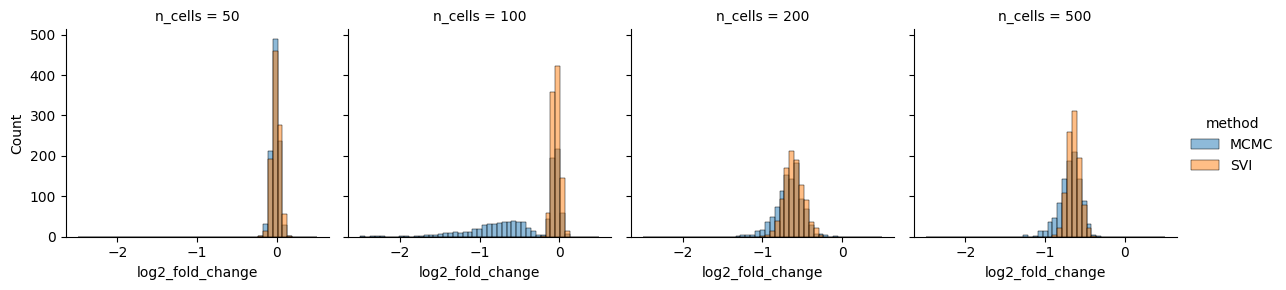

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

n_bins = 50

g = sns.FacetGrid(lfc_all_df, col="n_cells", hue="method", height=3, aspect=1)
g.map(sns.histplot, "log2_fold_change", alpha=0.5, bins=np.linspace(-2.5, 0.5, n_bins))
# Add a legend
g.add_legend()

plt.show()

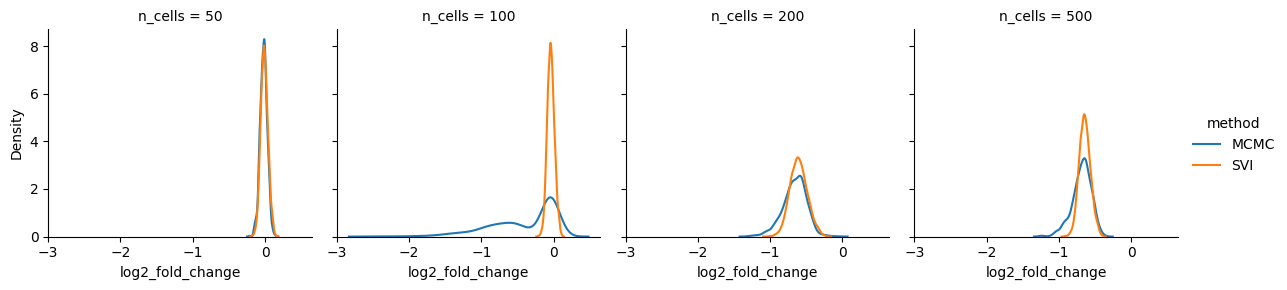

In [ ]:
g = sns.FacetGrid(lfc_all_df, col="n_cells", hue="method", height=3, aspect=1)
g.map(sns.kdeplot, "log2_fold_change")
g.add_legend()
plt.show()

In [ ]:
two_sided_threshold = 0.1
lfc_all_df.assign(lfc_significant=lambda x: abs(x["log2_fold_change"]) > two_sided_threshold).groupby(
    ["method", "n_cells"]
)["lfc_significant"].mean()

method  n_cells
MCMC    50         0.050
        100        0.552
        200        0.998
        500        1.000
SVI     50         0.046
        100        0.110
        200        1.000
        500        1.000
Name: lfc_significant, dtype: float64

In [ ]:
one_sided_threshold = -0.1
lfc_all_df.assign(lfc_significant=lambda x: x["log2_fold_change"] < one_sided_threshold).groupby(["method", "n_cells"])[
    "lfc_significant"
].mean()

method  n_cells
MCMC    50         0.043
        100        0.550
        200        0.998
        500        1.000
SVI     50         0.025
        100        0.108
        200        1.000
        500        1.000
Name: lfc_significant, dtype: float64